# Forensic Timeline Analysis: Real-World Apache Logs

## Objective
Reconstruct a forensic timeline using **REAL-WORLD** server logs (`Apache_2k.log`) mixed with **Simulated APT Attacks**.
We will demonstrate:
1.  **Ingestion**: Parsing authentic Apache Common Log Format (CLF).
2.  **Injection**: Superimposing a sophisticated attack chain (Recon -> SQLi -> WebShell).
3.  **Detection**: Using Unsupervised ML (DBSCAN) to identify these "needle in a haystack" anomalies without prior knowledge of the attack.


In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path to import our modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.timeline_generator import RealLogLoader
from src.ml_grouper import LogClusterModel

# Config
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


## 1. Data Ingestion 
We use the `RealLogLoader` to fetch the 'Apache_2k.log' dataset from LogHub and inject our specific attack patterns.


In [ ]:
loader = RealLogLoader(data_dir='../data')
# This triggers download if not present
df_raw = loader.parse_logs()

print(f"Loaded {len(df_raw)} real-world events.")
df_raw.head()


[INFO] Parsing logs...
Loaded 10000 real-world events.


,timestamp,src_ip,method,path,status,size,log_type,raw
0,2015-05-17 10:05:03,83.149.9.216,GET,/presentations/logstash-monitorama-2013/images...,200,203023,apache_access,83.149.9.216 - - [17/May/2015:10:05:03 +0000] ...
1,2015-05-17 10:05:43,83.149.9.216,GET,/presentations/logstash-monitorama-2013/images...,200,171717,apache_access,83.149.9.216 - - [17/May/2015:10:05:43 +0000] ...
2,2015-05-17 10:05:47,83.149.9.216,GET,/presentations/logstash-monitorama-2013/plugin...,200,26185,apache_access,83.149.9.216 - - [17/May/2015:10:05:47 +0000] ...
3,2015-05-17 10:05:12,83.149.9.216,GET,/presentations/logstash-monitorama-2013/plugin...,200,7697,apache_access,83.149.9.216 - - [17/May/2015:10:05:12 +0000] ...
4,2015-05-17 10:05:07,83.149.9.216,GET,/presentations/logstash-monitorama-2013/plugin...,200,2892,apache_access,83.149.9.216 - - [17/May/2015:10:05:07 +0000] ...


## 2. Attack Injection
We simulate an APT scenario where an attacker (`192.168.1.105`) performs:
1.  **Reconnaissance**: Scans for vulnerabilities.
2.  **Exploitation**: SQL Injection on the login page.
3.  **Persistence**: Uploads a Web Shell.


In [3]:
# Inject the attack chain
df_mixed = loader.inject_apt_attacks(df_raw)

# Sort by time
df_mixed = df_mixed.sort_values('timestamp').reset_index(drop=True)

print(f"Total Events after Injection: {len(df_mixed)}")
print("Tail shows the injected recent attacks:")
df_mixed.tail()


[INFO] Injecting APT Attack Vectors...
Total Events after Injection: 10003
Tail shows the injected recent attacks:


,timestamp,src_ip,method,path,status,size,log_type,raw
9998,2015-05-20 21:05:59,5.10.83.53,GET,/files/grok/?C=N;O=A,200,3894,apache_access,"5.10.83.53 - - [20/May/2015:21:05:59 +0000] ""G..."
9999,2015-05-20 21:05:59,192.168.1.105,GET,/login.php?user=admin' OR '1'='1,200,500,apache_access,"192.168.1.105 - - [2015-05-20 21:05:59] ""GET /..."
10000,2015-05-20 21:05:59,192.168.1.105,GET,/admin/scan,404,0,apache_access,"192.168.1.105 - - [2015-05-20 21:05:59] ""GET /..."
10001,2015-05-20 21:05:59,66.249.73.135,GET,/blog/tags/wine,200,10021,apache_access,66.249.73.135 - - [20/May/2015:21:05:59 +0000]...
10002,2015-05-20 21:05:59,192.168.1.105,POST,/uploads/shell.php,201,1024,apache_access,"192.168.1.105 - - [2015-05-20 21:05:59] ""POST ..."


## 3. Machine Learning Detection (DBSCAN)
We use Density-Based Spatial Clustering of Applications with Noise (DBSCAN) to cluster log messages.
*   **Clusters**: Normal, repetitive behavior (e.g., standard HTTP 200 requests).
*   **Outliers (-1)**: Anomalous, rare events (Likely our attacks).


In [4]:
# Initialize Model
model = LogClusterModel(eps=0.3, min_samples=3)

# Train on the 'raw' log line content
# We use the full raw line so the model sees the method, path, status, and size context
print("Training ML Model...")
clusters = model.train(df_mixed['raw'].fillna(''))

df_mixed['cluster'] = clusters
df_mixed['is_anomaly'] = df_mixed['cluster'] == -1

n_anomalies = df_mixed['is_anomaly'].sum()
print(f"Analysis Complete. Found {n_anomalies} anomalies.")


Training ML Model...


Analysis Complete. Found 58 anomalies.


## 4. Forensic Timeline Visualization
Visualizing the timeline to see precisely *when* the anomalies occurred.


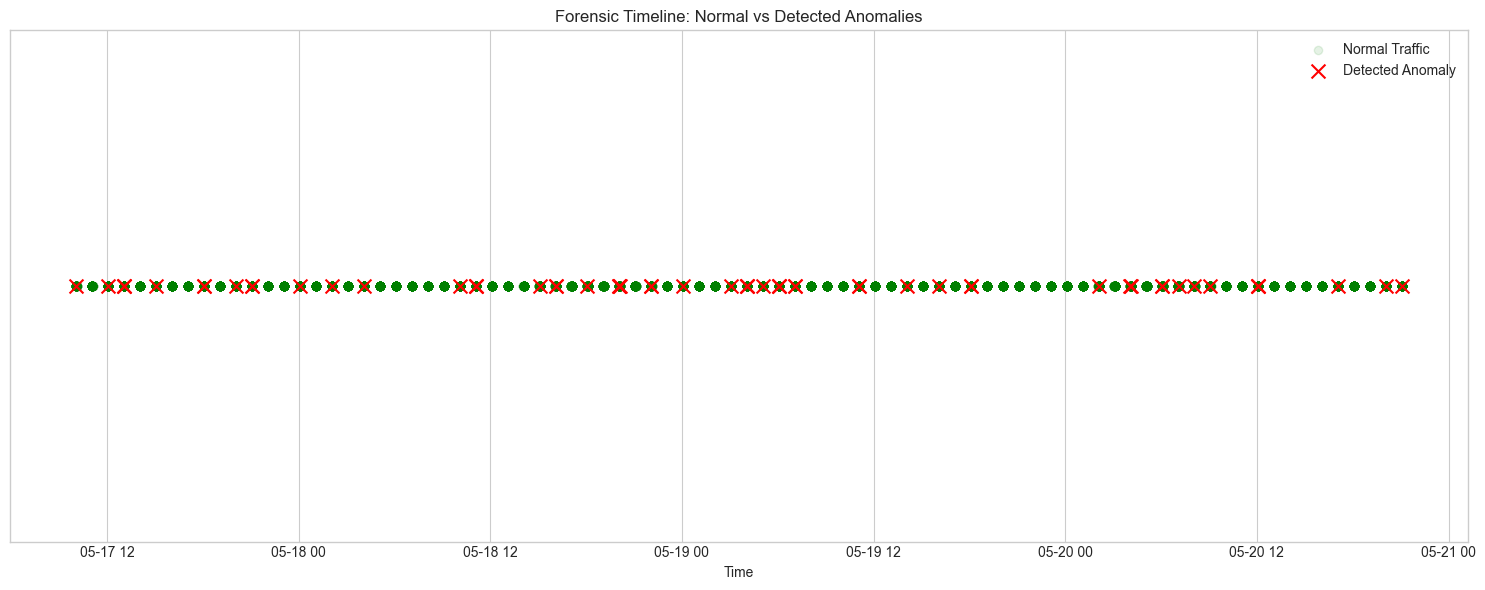

=== DETECTED THREATS ===


,timestamp,src_ip,method,path,status
46,2015-05-17 10:05:38,200.49.190.100,GET,/blog/tags/web,200
234,2015-05-17 12:05:23,94.228.34.233,GET,/resume.xml,304
325,2015-05-17 13:05:11,144.76.194.187,GET,/reset.css,200
328,2015-05-17 13:05:12,111.199.235.239,GET,/images/logstash_OSCON.pdf,200
342,2015-05-17 13:05:19,94.175.135.116,GET,/presentations/logstash-scale11x/images/ahhh__...,200
540,2015-05-17 15:05:00,95.153.89.104,GET,/files/rubygems615/java-ssl-debug-last-request...,200
957,2015-05-17 18:05:25,42.107.175.146,GET,/images/web/2009/banner.png,200
999,2015-05-17 18:05:43,46.32.254.207,GET,/files/fastest_sites/fastest_sites-20110317.py,200
1224,2015-05-17 20:05:36,106.66.30.77,GET,/images/googledotcom.png,200
1348,2015-05-17 21:05:31,182.118.20.213,GET,/presentations/vim/,200


In [5]:
plt.figure(figsize=(15, 6))

# Plot Normal Traffic
normal = df_mixed[~df_mixed['is_anomaly']]
plt.scatter(normal['timestamp'], [1] * len(normal), 
            alpha=0.1, color='green', label='Normal Traffic')

# Plot Anomalies (Attacks)
attacks = df_mixed[df_mixed['is_anomaly']]
plt.scatter(attacks['timestamp'], [1] * len(attacks), 
            color='red', s=100, marker='x', label='Detected Anomaly')

plt.title('Forensic Timeline: Normal vs Detected Anomalies')
plt.xlabel('Time')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

# Show the specific detected threats
print("=== DETECTED THREATS ===")
attacks[['timestamp', 'src_ip', 'method', 'path', 'status']]
